In [1]:
# Data manipulation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express 

# Model
#from functions import *
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.utils import to_categorical

In [2]:
df = pd.read_csv(rf'C:\Users\arthu\Documents\data.csv', sep=';')
df.head(3)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout


In [3]:
df['Target'].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [5]:
df.isna().sum()
#On vérifie qu'il ne manque aucune valeur même si le dataset est précisé comme complet

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [6]:
df.describe(include='all')

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN


In [7]:
for col in df.columns:
    print(df[col].value_counts(normalize=True))


Marital status
1    0.885850
2    0.085669
4    0.020570
5    0.005651
6    0.001356
3    0.000904
Name: proportion, dtype: float64
Application mode
1     0.386076
17    0.197107
39    0.177441
43    0.070524
44    0.048146
7     0.031420
18    0.028029
42    0.017405
51    0.013336
16    0.008590
53    0.007911
15    0.006781
5     0.003617
10    0.002260
2     0.000678
57    0.000226
26    0.000226
27    0.000226
Name: proportion, dtype: float64
Application order
1    0.683996
2    0.123644
3    0.069846
4    0.056284
5    0.034810
6    0.030967
9    0.000226
0    0.000226
Name: proportion, dtype: float64
Course
9500    0.173146
9147    0.085895
9238    0.080244
9085    0.076175
9773    0.074819
9670    0.060579
9991    0.060579
9254    0.056962
9070    0.051085
171     0.048599
8014    0.048599
9003    0.047468
9853    0.043400
9119    0.038427
9130    0.031872
9556    0.019439
33      0.002712
Name: proportion, dtype: float64
Daytime/evening attendance\t
1    0.890823
0    0.109177

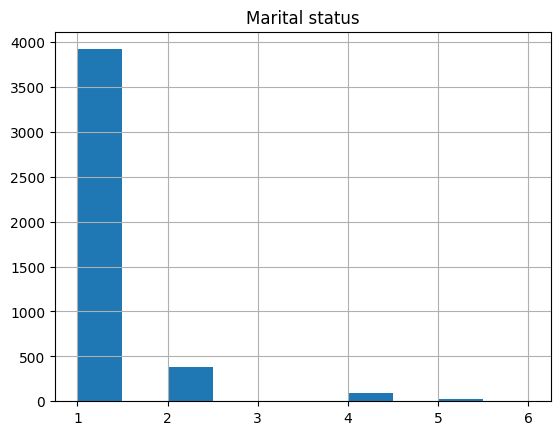

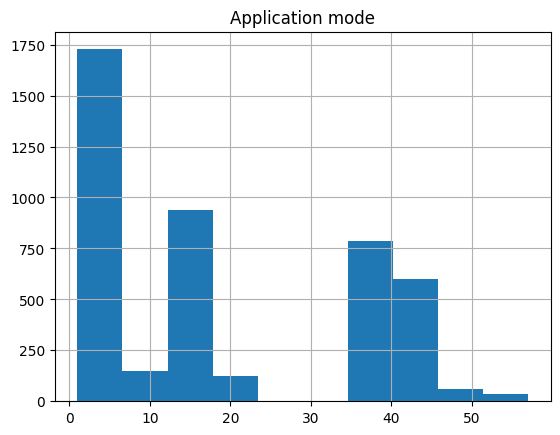

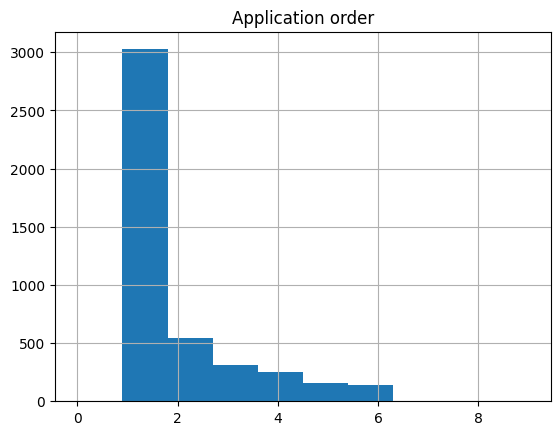

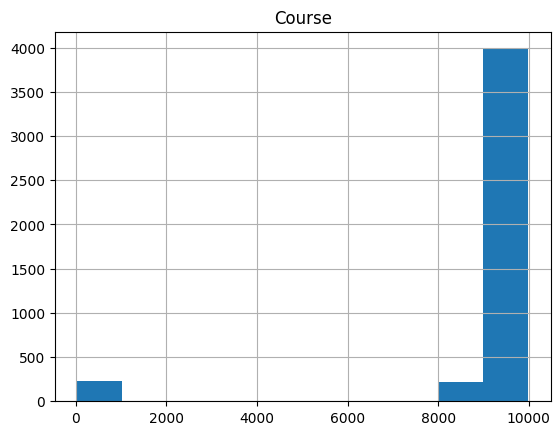

c:\Users\arthu\anaconda3\envs\Arthur\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


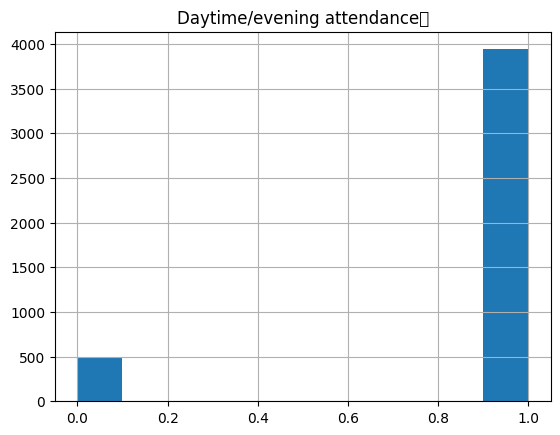

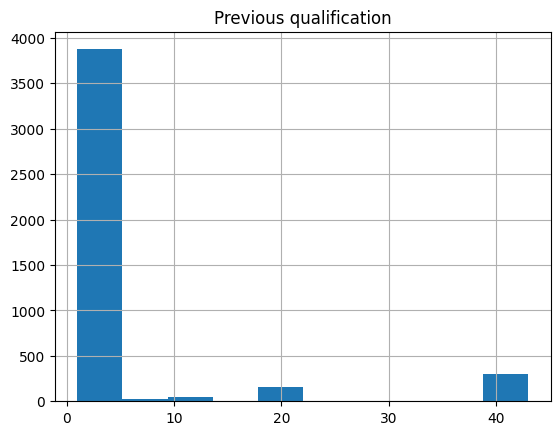

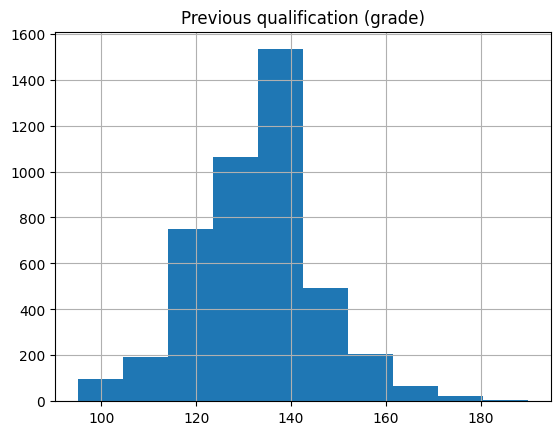

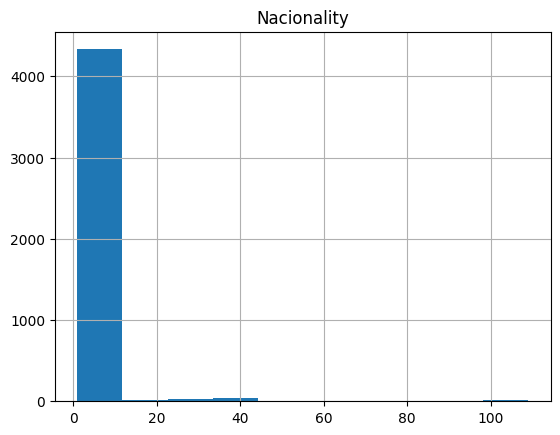

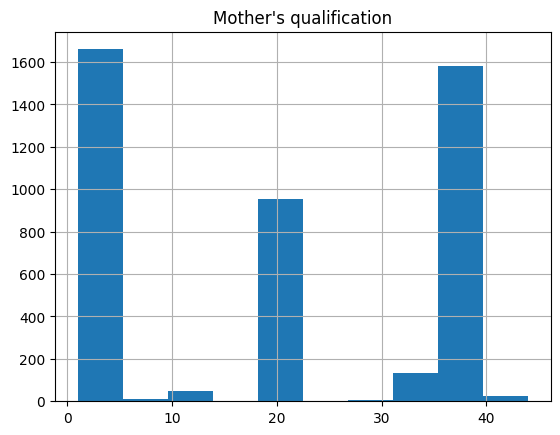

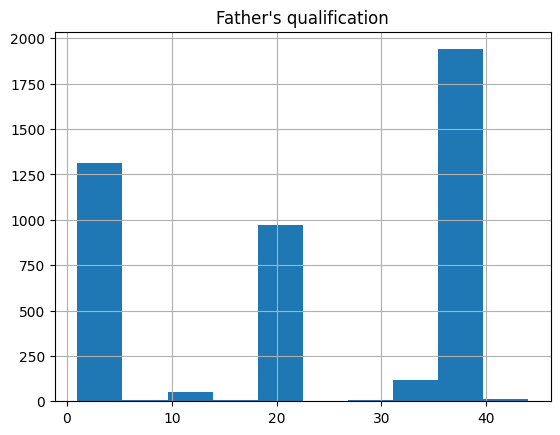

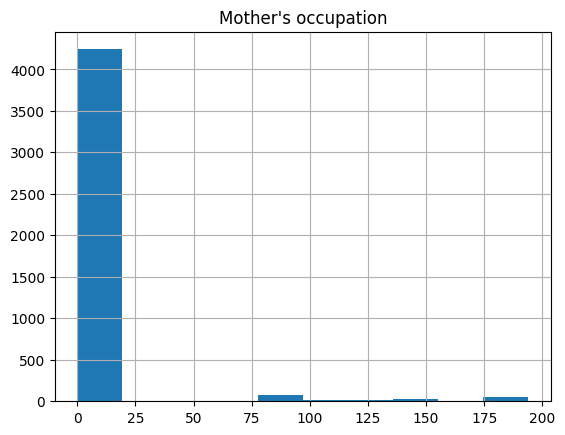

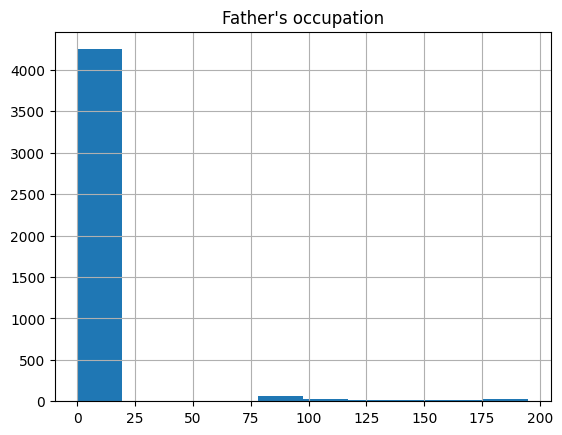

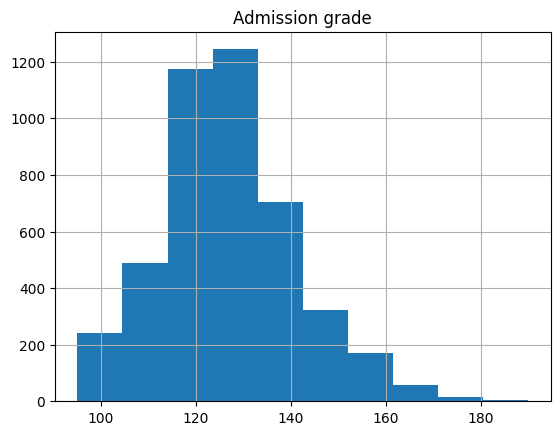

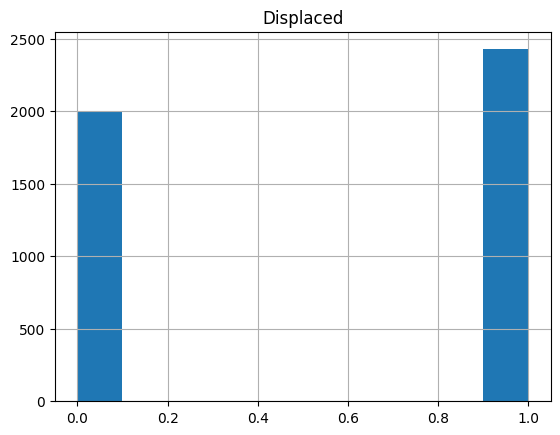

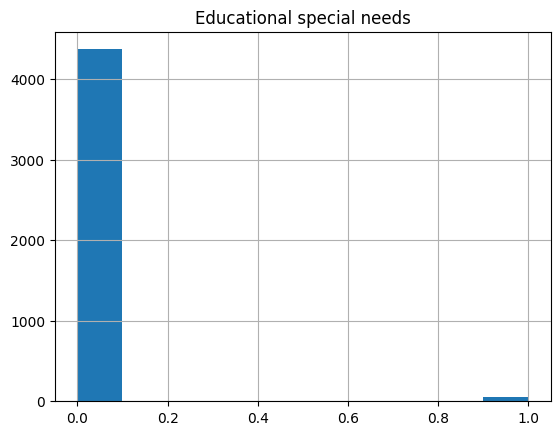

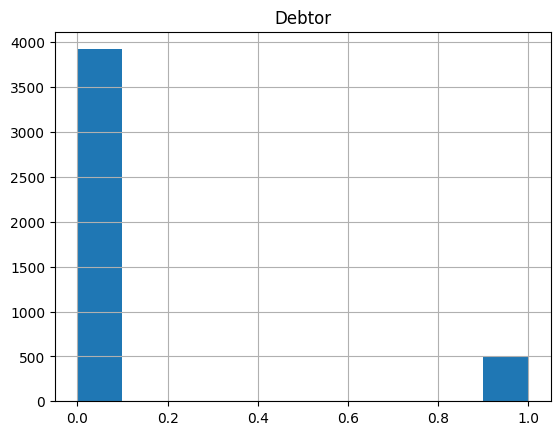

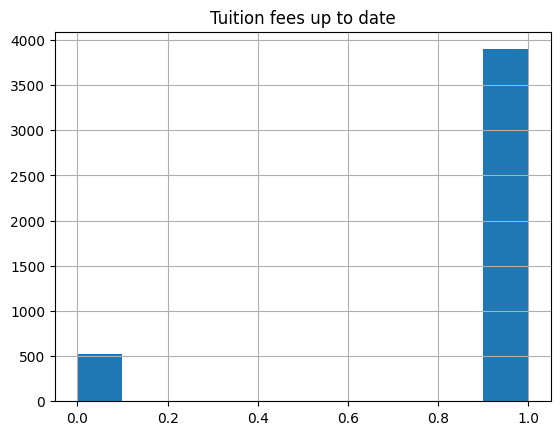

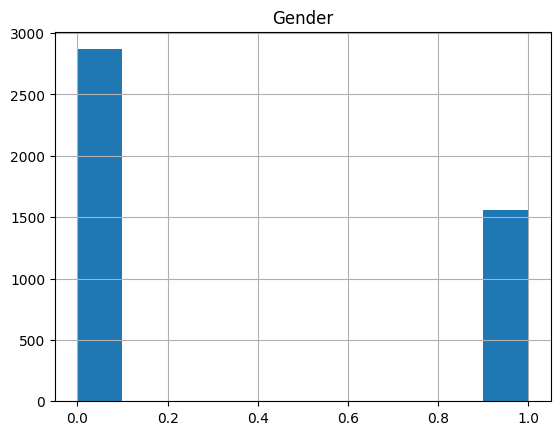

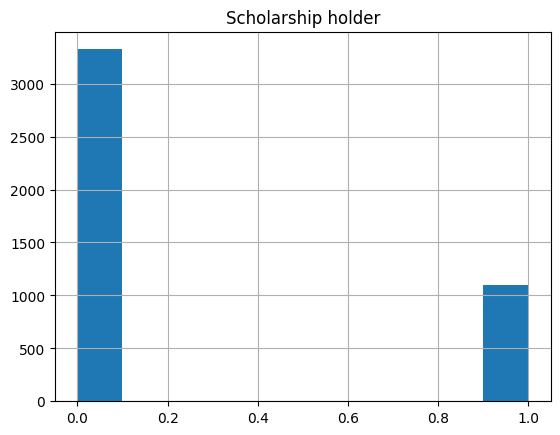

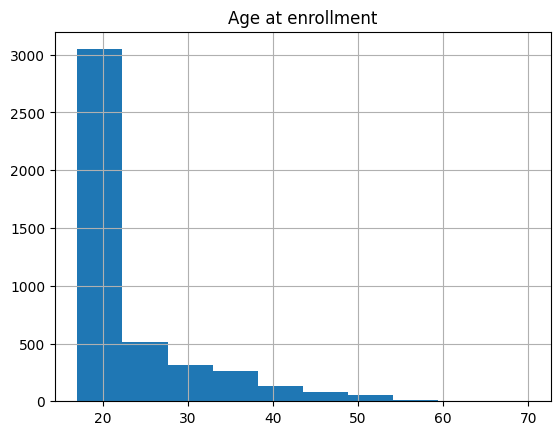

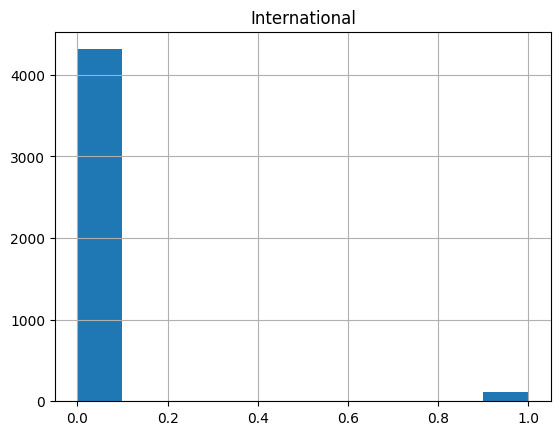

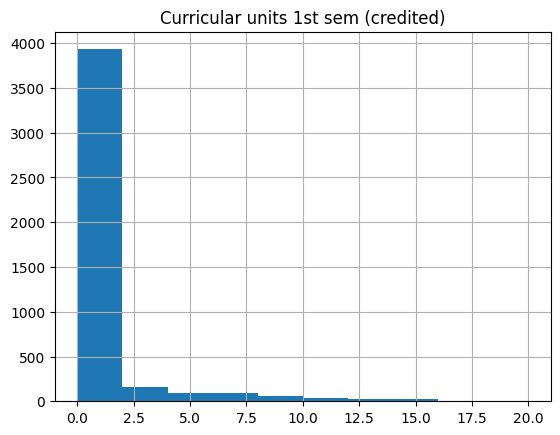

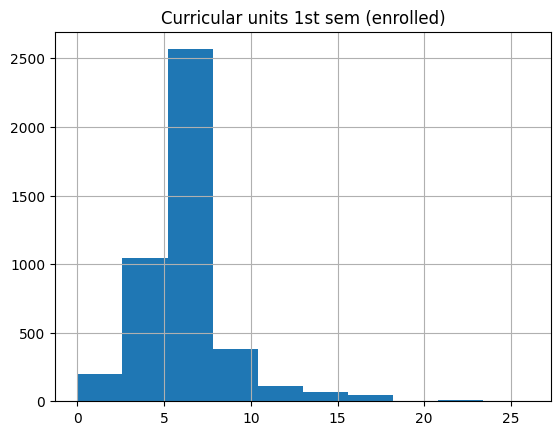

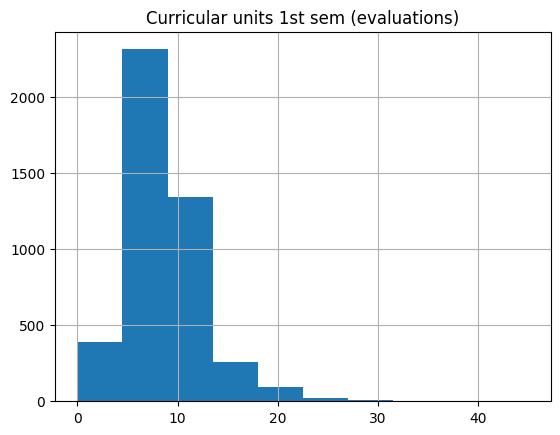

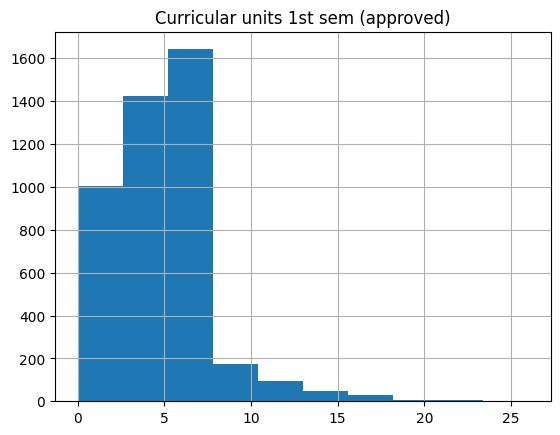

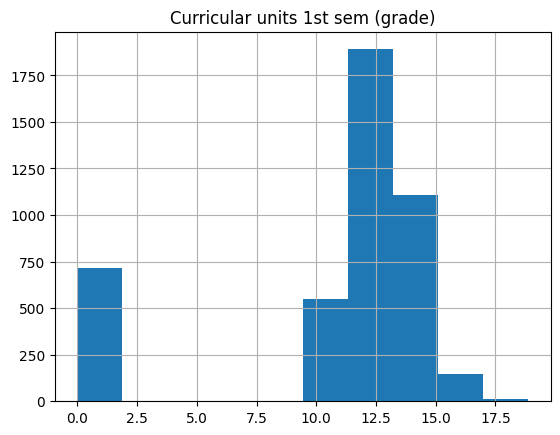

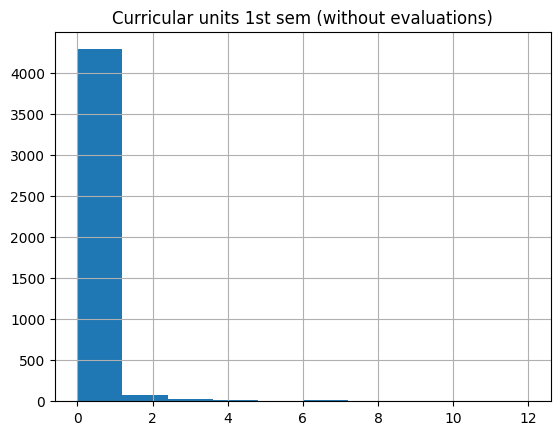

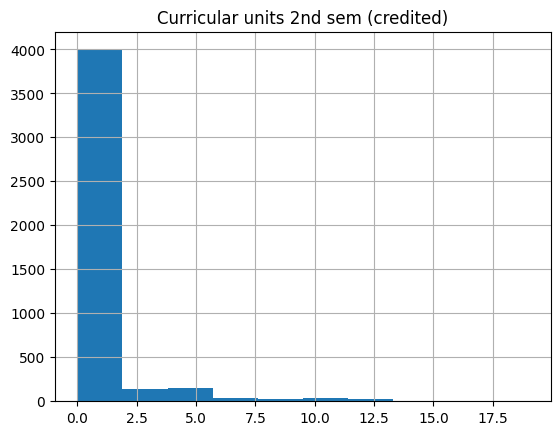

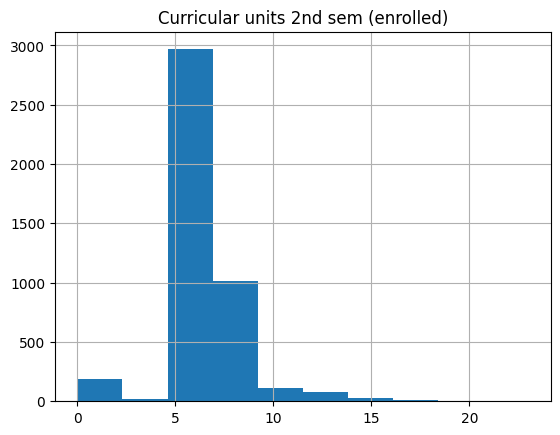

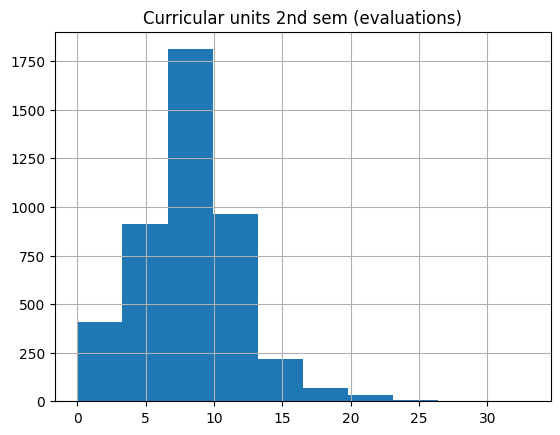

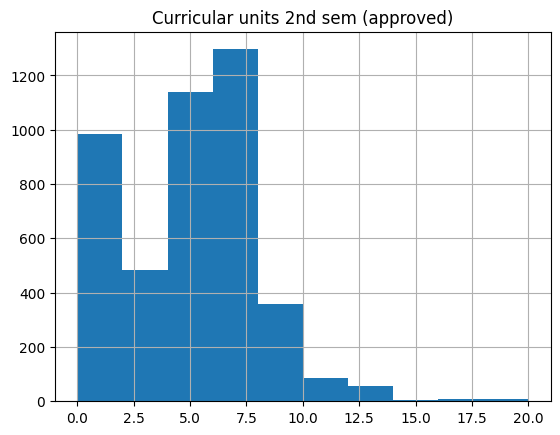

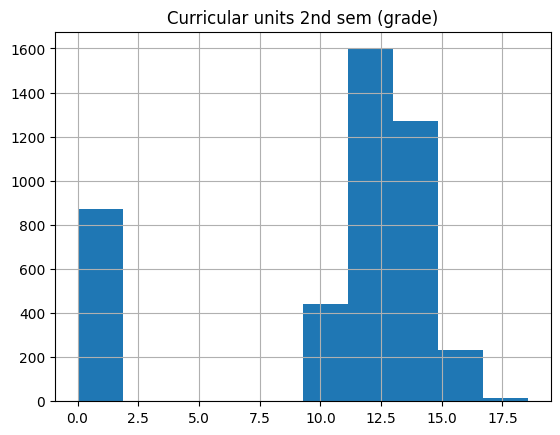

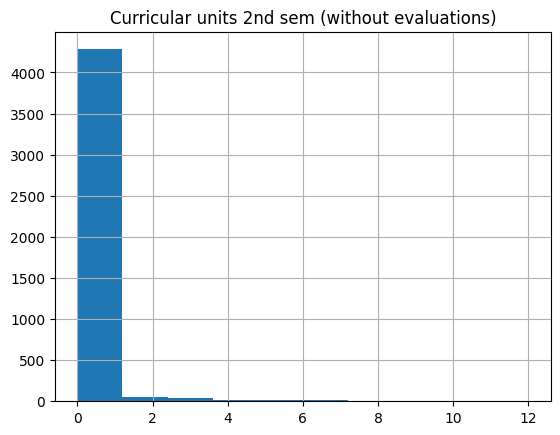

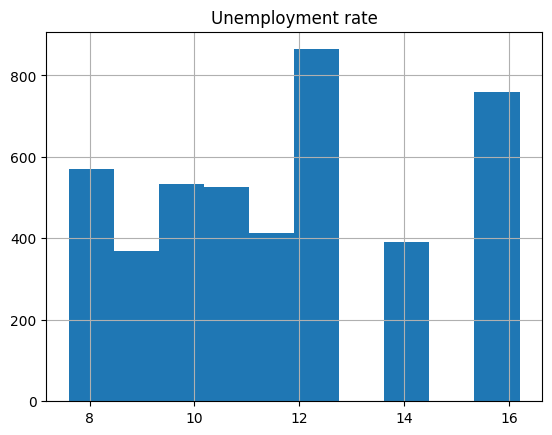

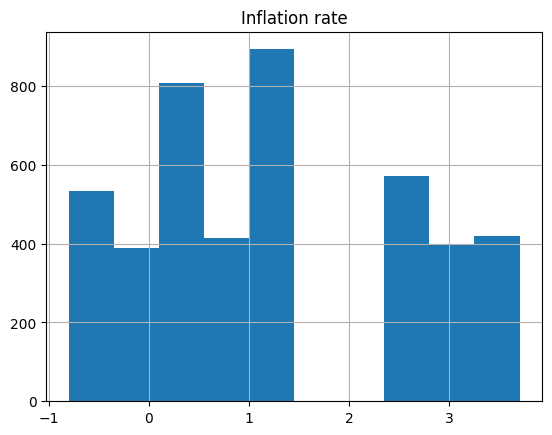

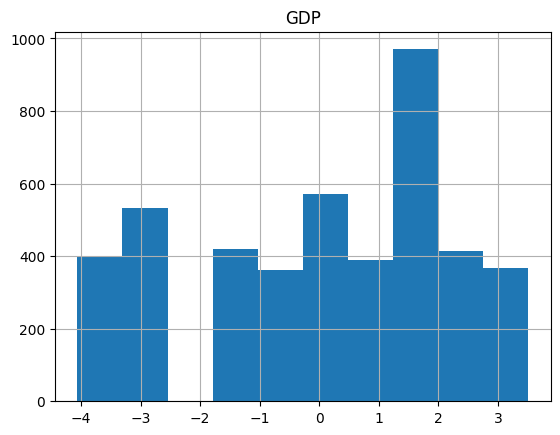

In [8]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:  # Ensure the column is numeric
        df[col].hist()
        plt.title(col)
        plt.show()

In [9]:
plotly.express.box(df, x= 'Target', y='Tuition fees up to date', title='Boxplot of Target')

Ne pas avoir les frais de scolarité à jour est une caractéristique présente uniquement chez les étudiants n'ayant pas réussi leur année

In [10]:
#notes = pd.cut(df['Admission grade'], bins=[0,70,140,200],labels =['Raté','Moyen','Réussi'])#.value_counts(normalize=True)
#df.drop('Notes', axis=1, inplace=True)
#df.insert (2, 'Notes', notes)

In [11]:
#df['Notes'].value_counts(normalize=True)

In [12]:
fig = plotly.express.box(df, x='Target', y='Admission grade', color='Target',
             title='Distribution des notes d\'admission par catégorie de Target')
fig.show()

On voulait vérifier si les notes au test d'admision avait un impact significatif sur la réussite des examens mais cela n'a pas l'air d'être assez significatif. Il y a un peu plus de personne qui avait de bonnes notes chez les diplomés, un peu moins chez les redoublant et un peu moins chez ceux qui ont abandonné mais rien de significatif

In [13]:
fig = plotly.express.box(df, x='Target', y='Age at enrollment', color='Target',
             title='Distribution des notes d\'admission par catégorie de Target')
fig.show()

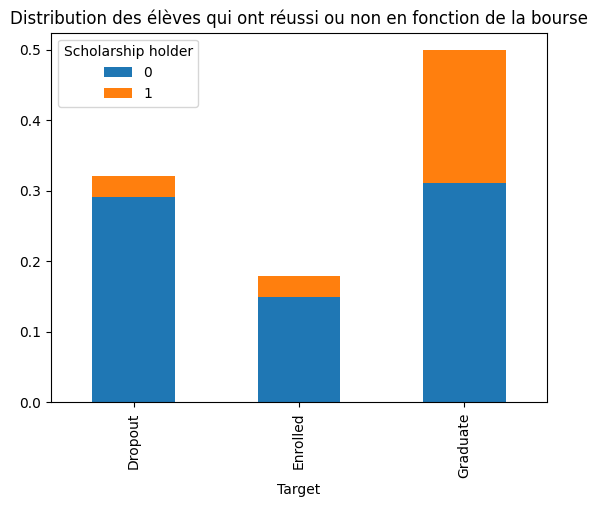

In [14]:
crosstab = pd.crosstab(df['Target'], df['Scholarship holder'], normalize=True)
crosstab.plot(kind='bar', stacked=True)
plt.title(f'Distribution des élèves qui ont réussi ou non en fonction de la bourse')
plt.show()

Les élèves qui ont une bourse sont plus enclin à réussir leur année

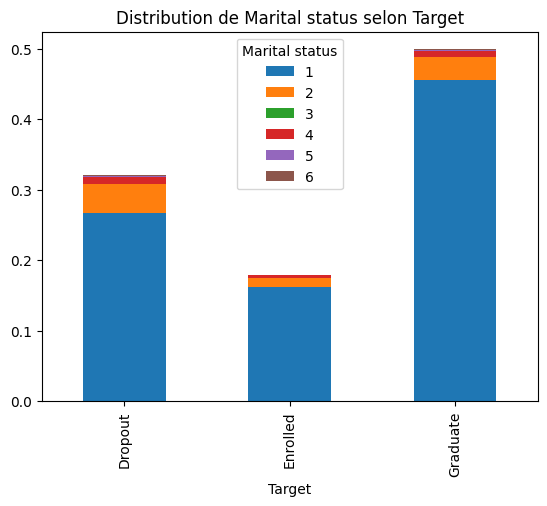

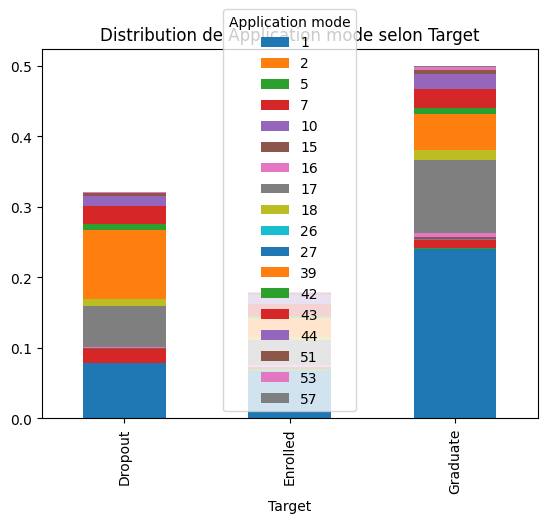

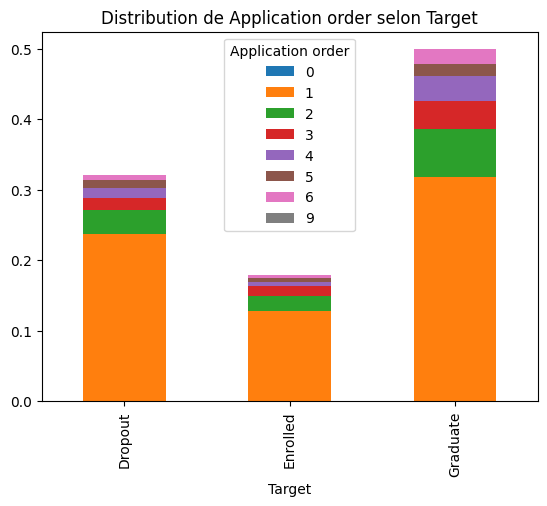

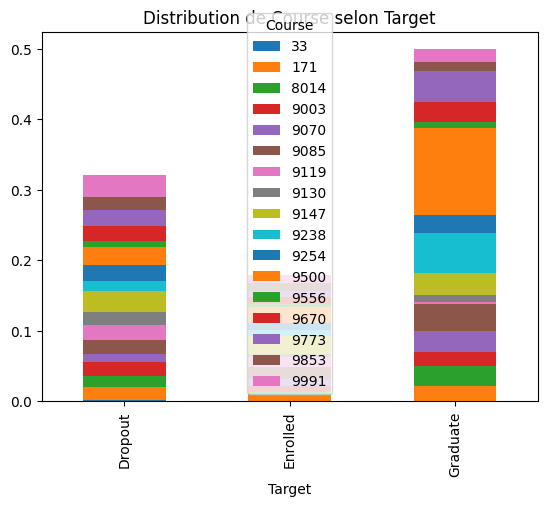

c:\Users\arthu\anaconda3\envs\Arthur\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 9 (	) missing from font(s) DejaVu Sans.



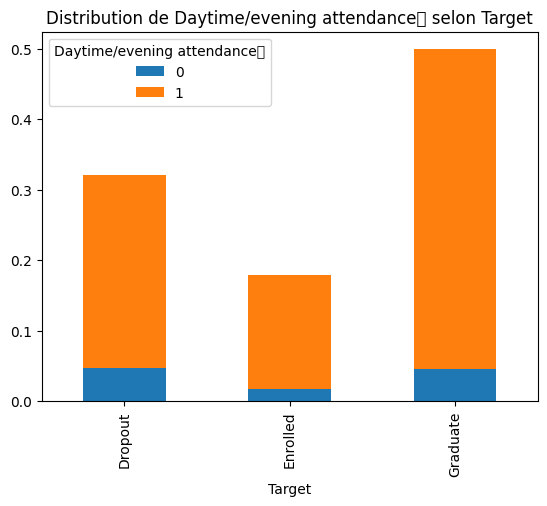

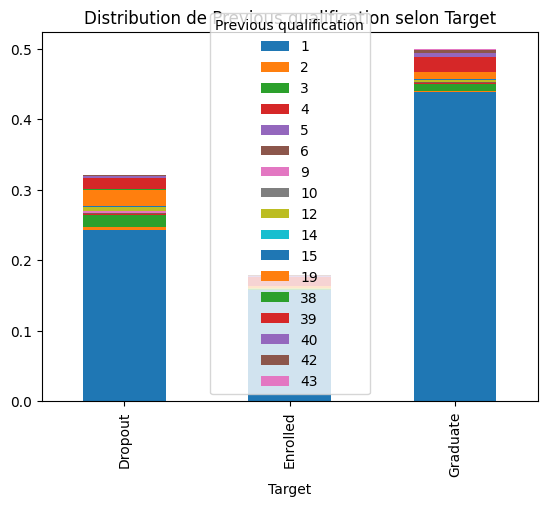

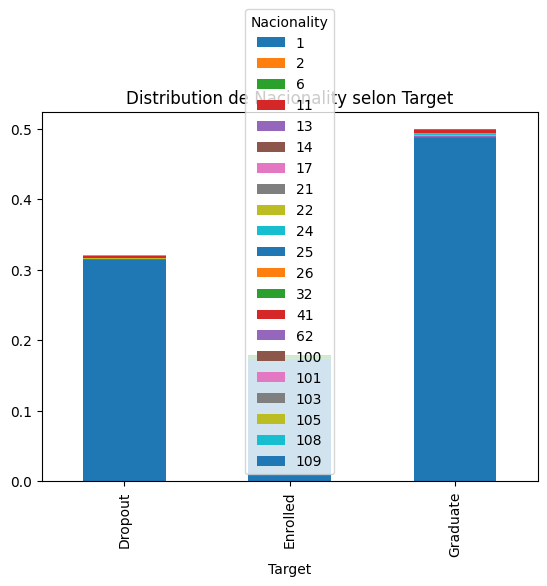

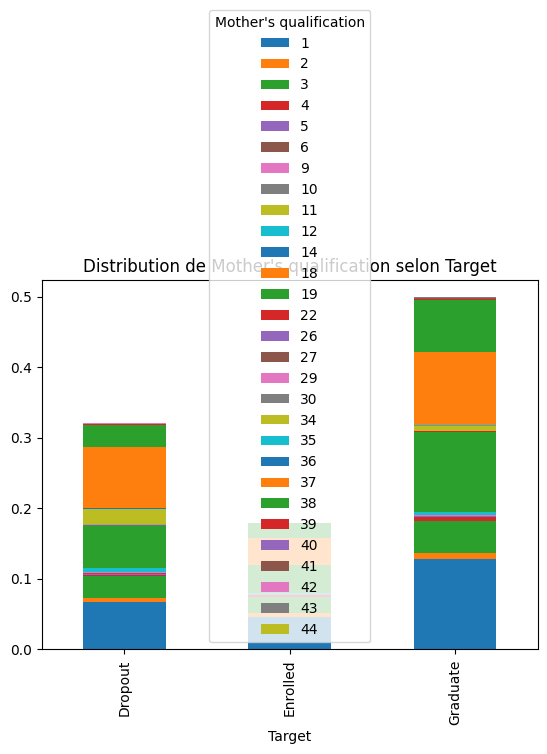

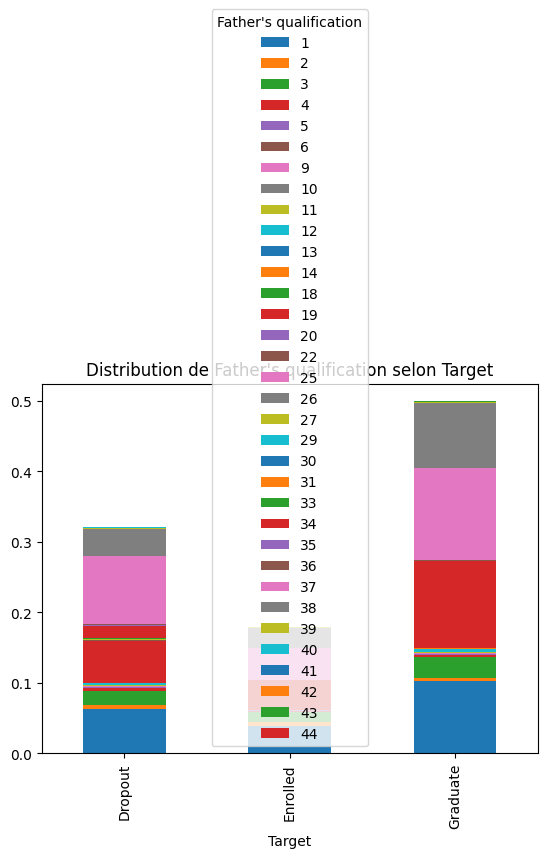

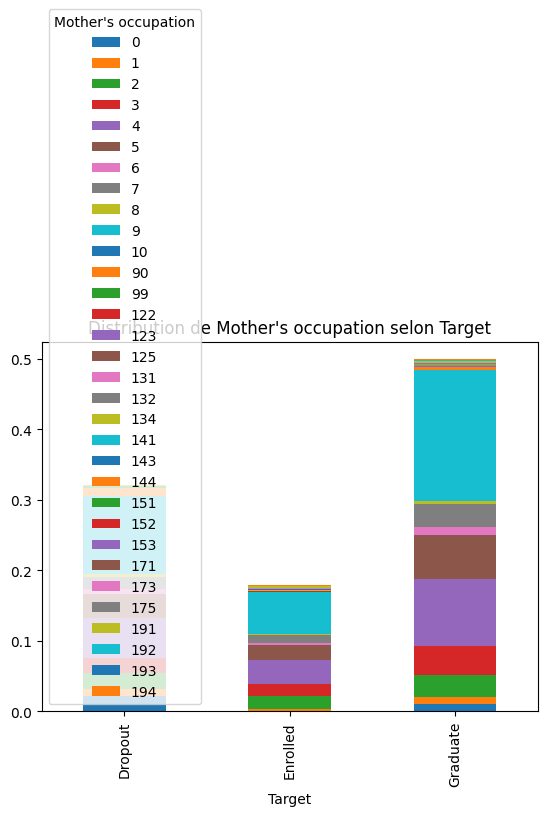

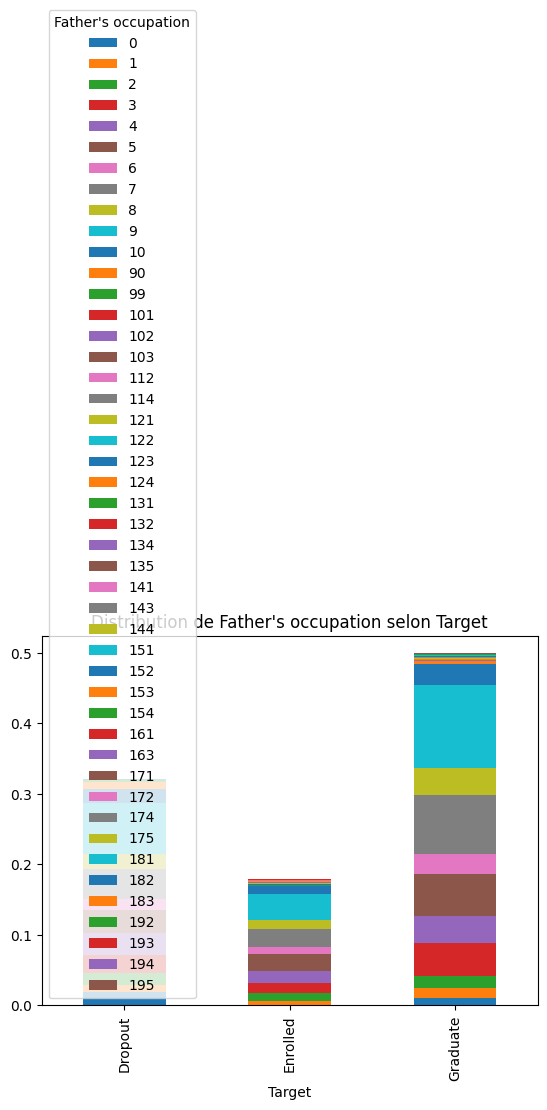

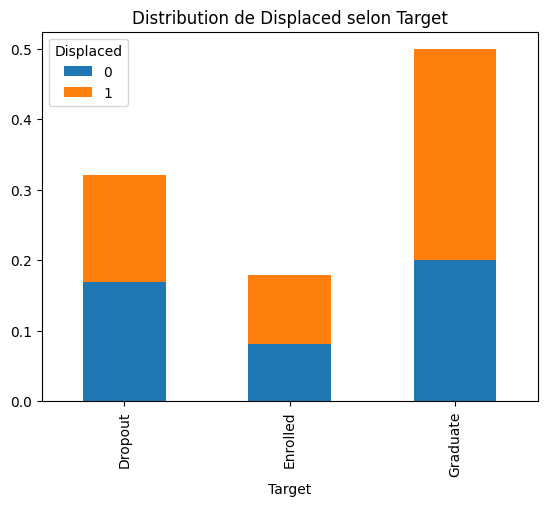

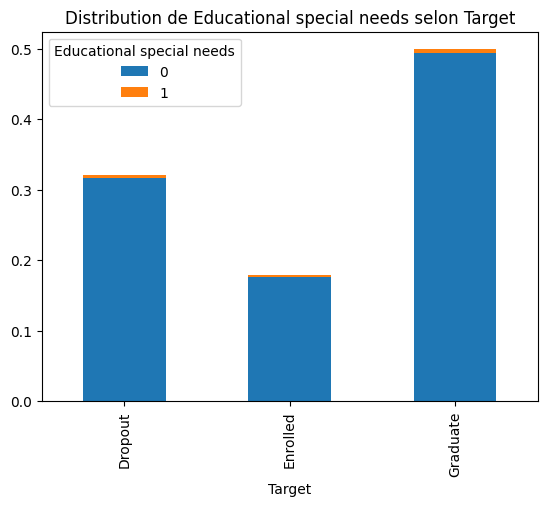

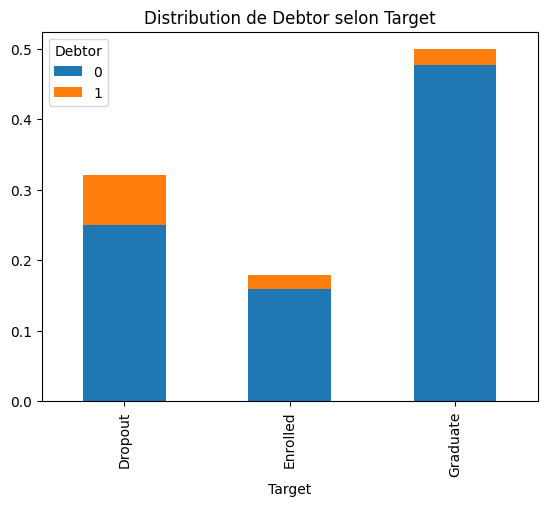

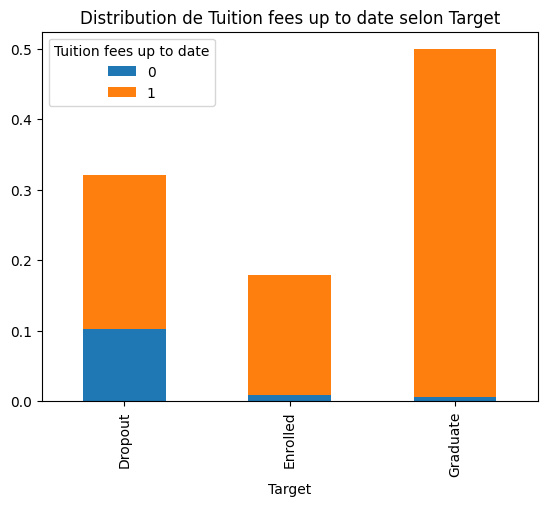

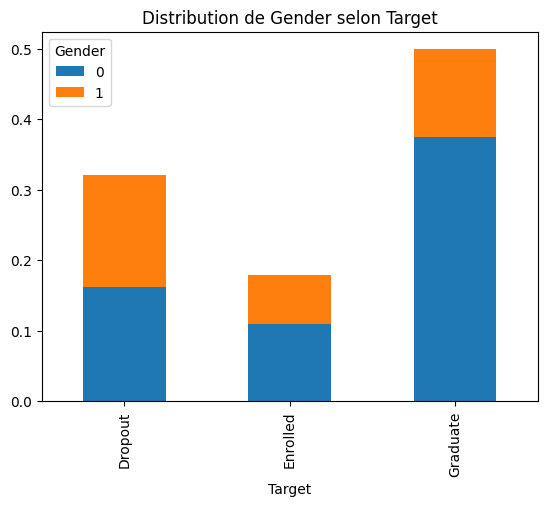

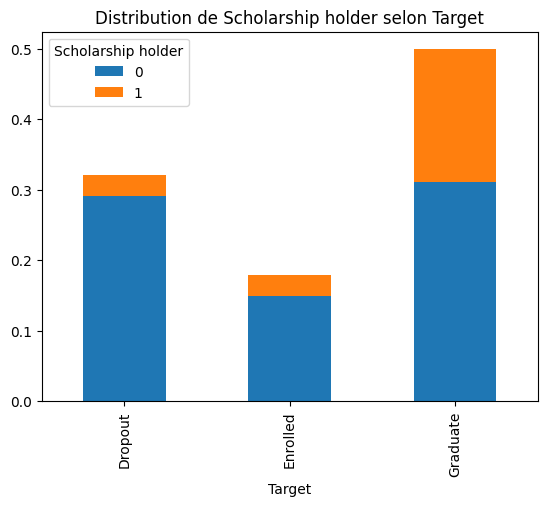

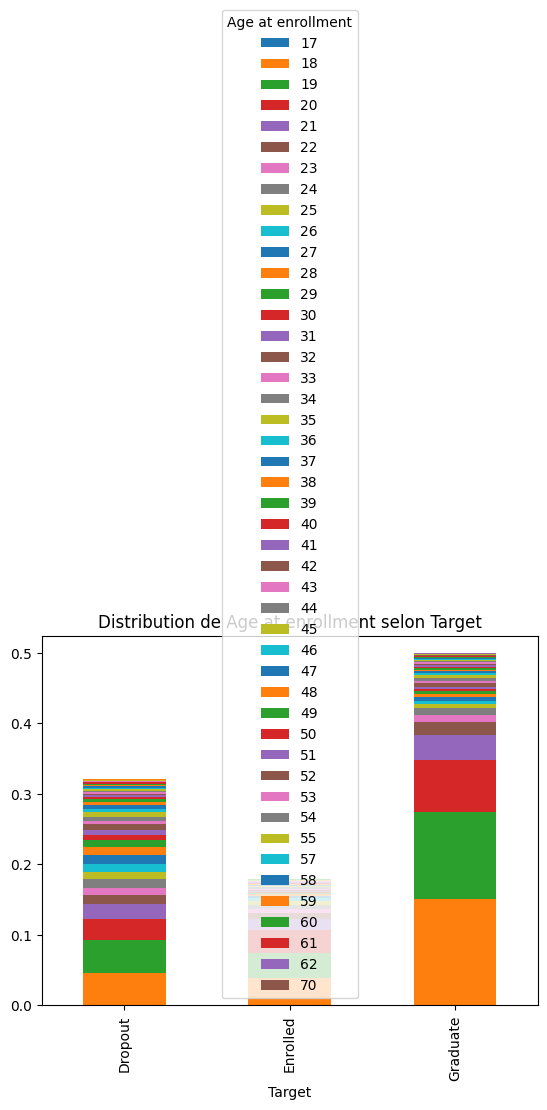

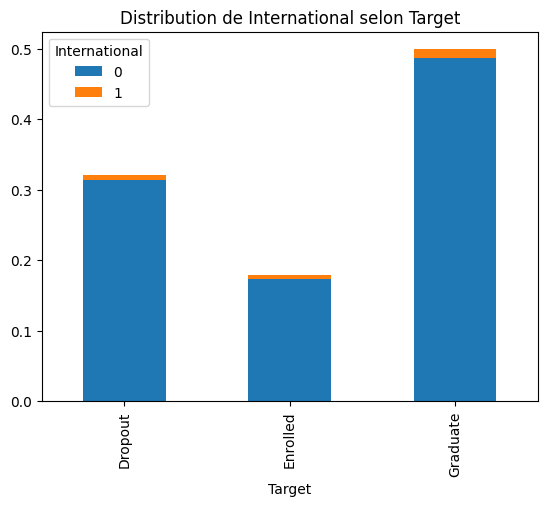

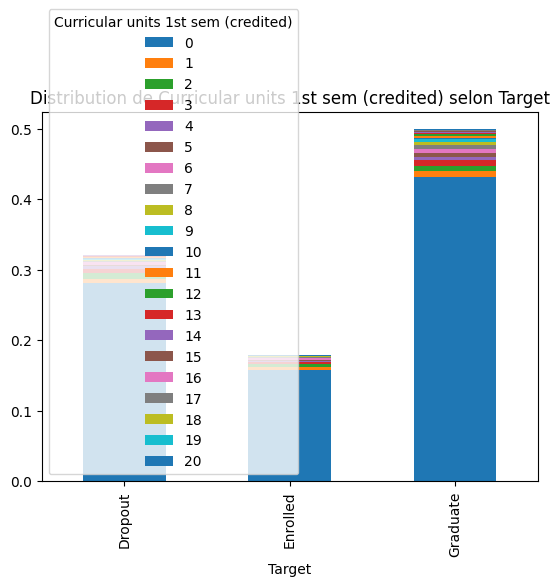

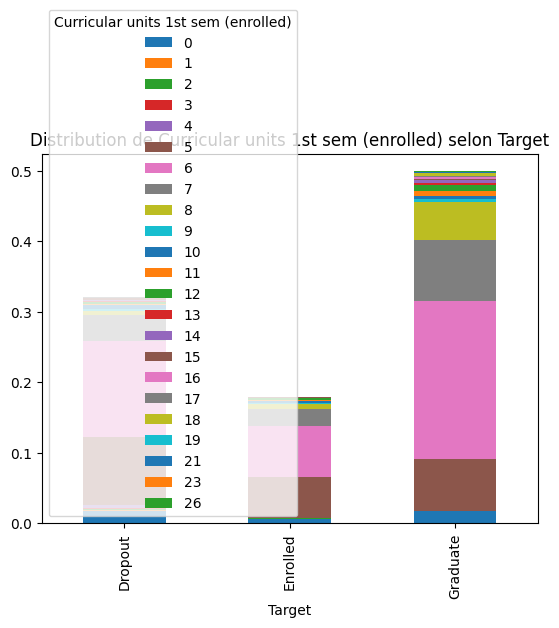

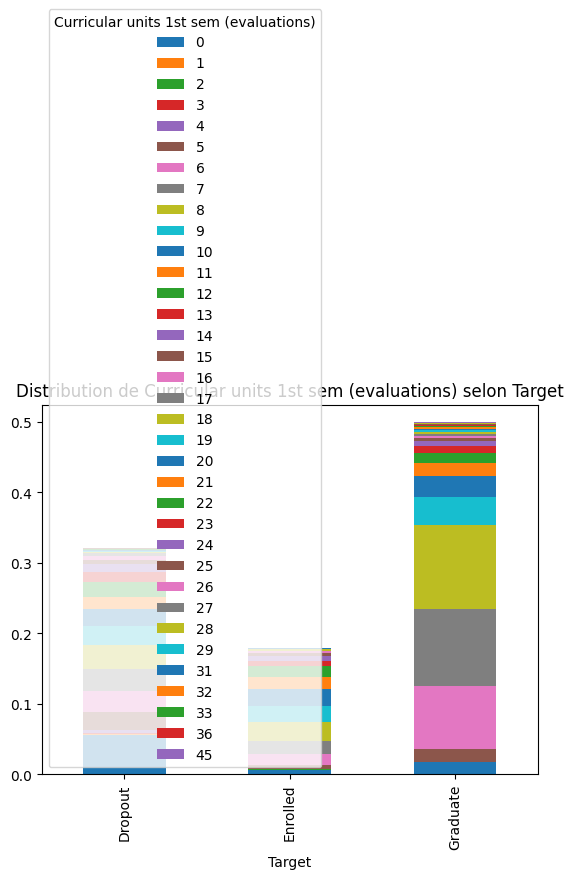

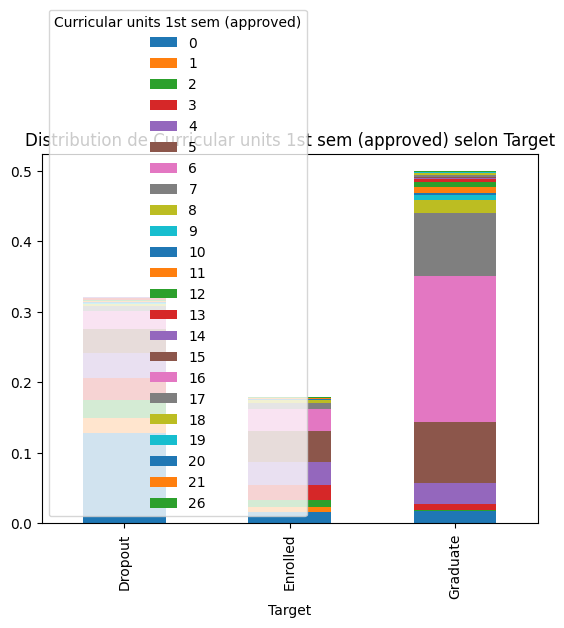

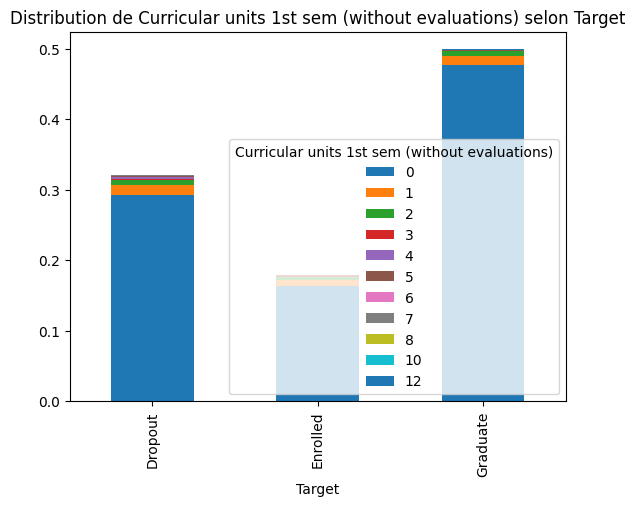

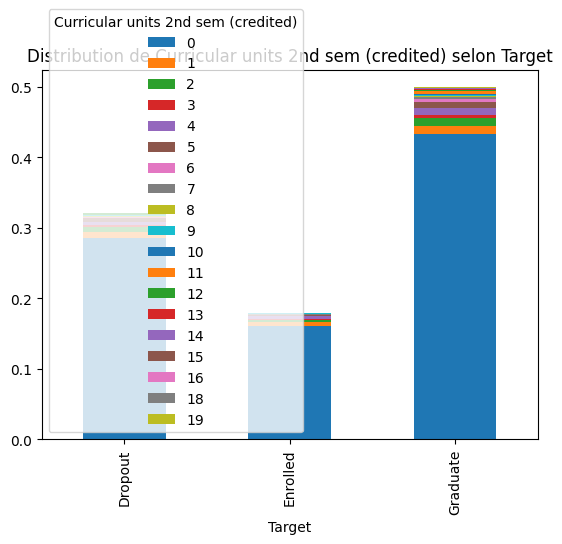

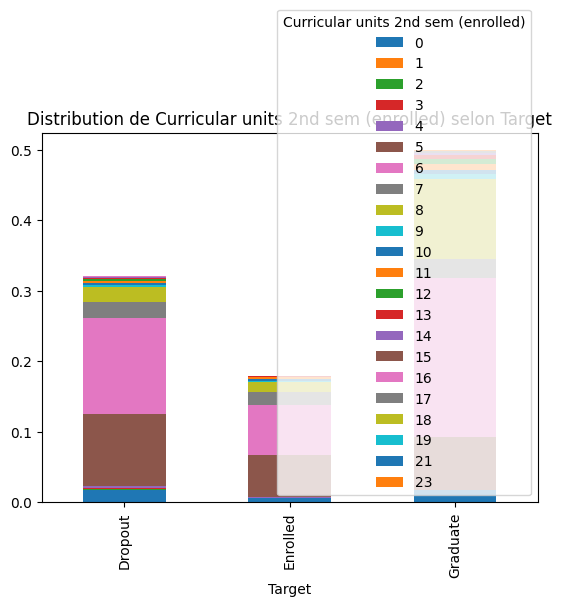

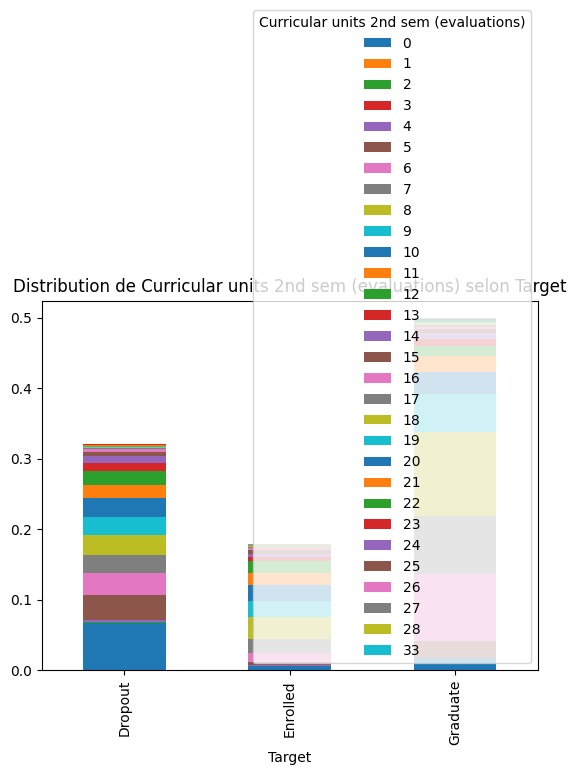

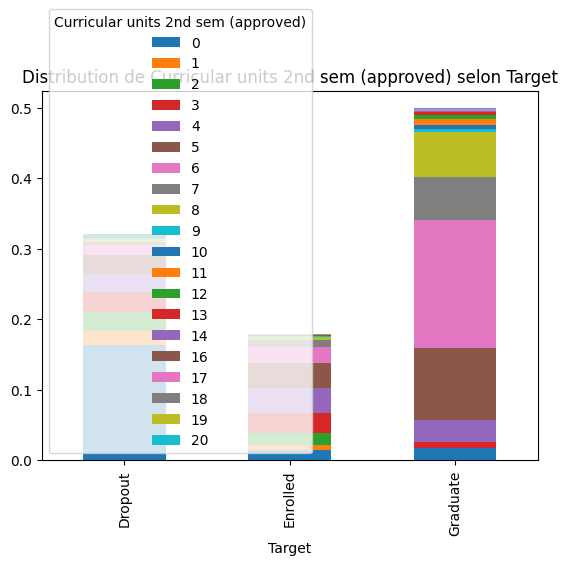

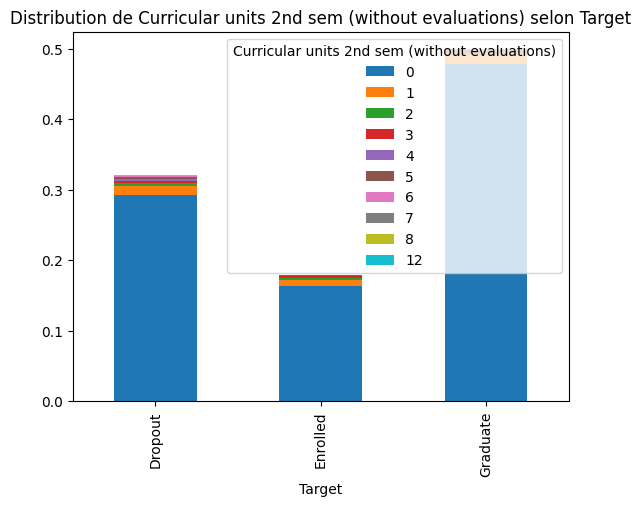

In [15]:
# Filtrer les colonnes catégorielles
colonnes_categoriques = [col for col in df.columns if df[col].dtype == 'int64' and df[col].dtype != 'object']
colonnes_continues = [col for col in df.columns if col not in colonnes_categoriques and df[col].dtype != 'object'] 
# Boucle sur les colonnes catégoriques seulement
for col in colonnes_categoriques:
    crosstab = pd.crosstab(df['Target'], df[col], normalize=True)
    crosstab.plot(kind='bar', stacked=True)
    plt.title(f'Distribution de {col} selon Target')
    plt.show()


In [16]:
#df.drop('Notes', axis=1, inplace=True)

In [17]:
import pandas as pd
import numpy as np
import plotly.express as px
from scipy.stats import shapiro, kruskal
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

for col in colonnes_continues:
    # Tableau croisé : découpage de la variable en 10 intervalles
    binned = pd.cut(df[col], bins=10)
    ctab = pd.crosstab(df['Target'], binned)
    print(f"\nCrosstab pour {col}:")
    print(ctab)
    
    # Histogramme interactif avec Plotly Express
    fig_hist = px.histogram(df, x=col, nbins=30, 
                            title=f'Histogramme interactif de {col}',
                            labels={col: col},
                            marginal="rug")  # Ajoute un rug plot pour la distribution
    fig_hist.show()
    
    # Boxplot interactif avec Plotly Express
    fig_box = px.box(df, x=col, 
                     title=f'Boxplot interactif de {col}',
                     labels={col: col})
    fig_box.show()

    
    # Test non paramétrique : Kruskal-Wallis pour comparer les groupes définis par 'Target'
    groupes = [g[col].dropna() for name, g in df.groupby('Target')]
    stat_kw, p_kw = kruskal(*groupes)
    print(f"Test de Kruskal-Wallis pour {col} entre les groupes Target : p-value = {p_kw:.5f}")
    if p_kw < 0.05:
        print("→ Il existe des différences significatives entre les groupes.")
    else:
        print("→ Aucune différence significative entre les groupes.")
    
    print("------------------------------------------------")


Crosstab pour Previous qualification (grade):
Previous qualification (grade)  (94.905, 104.5]  (104.5, 114.0]  \
Target                                                            
Dropout                                      32              91   
Enrolled                                     20              35   
Graduate                                     44              88   

Previous qualification (grade)  (114.0, 123.5]  (123.5, 133.0]  \
Target                                                           
Dropout                                    260             321   
Enrolled                                   156             240   
Graduate                                   312             589   

Previous qualification (grade)  (133.0, 142.5]  (142.5, 152.0]  \
Target                                                           
Dropout                                    530             118   
Enrolled                                   226              77   
Graduate              

Test de Kruskal-Wallis pour Previous qualification (grade) entre les groupes Target : p-value = 0.00000
→ Il existe des différences significatives entre les groupes.
------------------------------------------------

Crosstab pour Admission grade:
Admission grade  (94.905, 104.5]  (104.5, 114.0]  (114.0, 123.5]  \
Target                                                             
Dropout                      127             197             386   
Enrolled                      44             103             238   
Graduate                      72             198             551   

Admission grade  (123.5, 133.0]  (133.0, 142.5]  (142.5, 152.0]  \
Target                                                            
Dropout                     356             201              82   
Enrolled                    208             121              53   
Graduate                    690             366             187   

Admission grade  (152.0, 161.5]  (161.5, 171.0]  (171.0, 180.5]  \
Target   

Test de Kruskal-Wallis pour Admission grade entre les groupes Target : p-value = 0.00000
→ Il existe des différences significatives entre les groupes.
------------------------------------------------

Crosstab pour Curricular units 1st sem (grade):
Curricular units 1st sem (grade)  (-0.0189, 1.888]  (9.438, 11.325]  \
Target                                                                
Dropout                                        570              230   
Enrolled                                        71              172   
Graduate                                        77              147   

Curricular units 1st sem (grade)  (11.325, 13.212]  (13.212, 15.1]  \
Target                                                               
Dropout                                        467             131   
Enrolled                                       410             131   
Graduate                                      1012             846   

Curricular units 1st sem (grade)  (15.1, 16.

Test de Kruskal-Wallis pour Curricular units 1st sem (grade) entre les groupes Target : p-value = 0.00000
→ Il existe des différences significatives entre les groupes.
------------------------------------------------

Crosstab pour Curricular units 2nd sem (grade):
Curricular units 2nd sem (grade)  (-0.0186, 1.857]  (9.286, 11.143]  \
Target                                                                
Dropout                                        727              207   
Enrolled                                        68              159   
Graduate                                        75               83   

Curricular units 2nd sem (grade)  (11.143, 13.0]  (13.0, 14.857]  \
Target                                                             
Dropout                                      336             122   
Enrolled                                     414             139   
Graduate                                     989             865   

Curricular units 2nd sem (grade)  (14

Test de Kruskal-Wallis pour Curricular units 2nd sem (grade) entre les groupes Target : p-value = 0.00000
→ Il existe des différences significatives entre les groupes.
------------------------------------------------

Crosstab pour Unemployment rate:
Unemployment rate  (7.591, 8.46]  (8.46, 9.32]  (9.32, 10.18]  (10.18, 11.04]  \
Target                                                                          
Dropout                      202           102            174             182   
Enrolled                     119            77            109              90   
Graduate                     250           189            250             253   

Unemployment rate  (11.04, 11.9]  (11.9, 12.76]  (13.62, 14.48]  (15.34, 16.2]  
Target                                                                          
Dropout                      117            248             118            278  
Enrolled                      67            153              64            115  
Graduate           

Test de Kruskal-Wallis pour Unemployment rate entre les groupes Target : p-value = 0.00160
→ Il existe des différences significatives entre les groupes.
------------------------------------------------

Crosstab pour Inflation rate:
Inflation rate  (-0.804, -0.35]  (-0.35, 0.1]  (0.1, 0.55]  (0.55, 1.0]  \
Target                                                                    
Dropout                     174           118          246          117   
Enrolled                    109            64          136           67   
Graduate                    250           208          425          230   

Inflation rate  (1.0, 1.45]  (2.35, 2.8]  (3.25, 3.7]  
Target                                                 
Dropout                 284          341          141  
Enrolled                167          188           63  
Graduate                442          439          215  


Test de Kruskal-Wallis pour Inflation rate entre les groupes Target : p-value = 0.29556
→ Aucune différence significative entre les groupes.
------------------------------------------------

Crosstab pour GDP:
GDP       (-4.068, -3.303]  (-3.303, -2.546]  (-1.789, -1.032]  \
Target                                                           
Dropout                139               174               141   
Enrolled                69               109                63   
Graduate               189               250               215   

GDP       (-1.032, -0.275]  (-0.275, 0.482]  (0.482, 1.239]  (1.239, 1.996]  \
Target                                                                        
Dropout                139              202             118             289   
Enrolled                46              119              64             180   
Graduate               177              250             208             501   

GDP       (1.996, 2.753]  (2.753, 3.51]  
Target               

Test de Kruskal-Wallis pour GDP entre les groupes Target : p-value = 0.00074
→ Il existe des différences significatives entre les groupes.
------------------------------------------------


In [18]:
# Exemple d'exploration : afficher la médiane de chaque variable continue par groupe Target
for col in colonnes_continues:
    medians = df.groupby('Target')[col].median()
    print(f"Médiane de {col} par groupe Target :")
    print(medians)
    print("------------------------------------------------")

Médiane de Previous qualification (grade) par groupe Target :
Target
Dropout     133.1
Enrolled    130.0
Graduate    133.1
Name: Previous qualification (grade), dtype: float64
------------------------------------------------
Médiane de Admission grade par groupe Target :
Target
Dropout     123.6
Enrolled    124.1
Graduate    127.4
Name: Admission grade, dtype: float64
------------------------------------------------
Médiane de Curricular units 1st sem (grade) par groupe Target :
Target
Dropout     10.928571
Enrolled    12.000000
Graduate    13.000000
Name: Curricular units 1st sem (grade), dtype: float64
------------------------------------------------
Médiane de Curricular units 2nd sem (grade) par groupe Target :
Target
Dropout      0.0
Enrolled    12.0
Graduate    13.0
Name: Curricular units 2nd sem (grade), dtype: float64
------------------------------------------------
Médiane de Unemployment rate par groupe Target :
Target
Dropout     11.1
Enrolled    11.1
Graduate    11.1
Name: 

Ces médianes :
Les notes d'admission et les notes obtenues durant les semestres semblent être des indicateurs plus clairs du succès académique (diplôme). Des médianes plus élevées sont associées à une plus grande probabilité d'obtention du diplôme.
La médiane de la note de qualification précédente ne montre pas de différence notable entre les diplômés et les décrocheurs.
Les facteurs macroéconomiques comme le taux de chômage ne semblent pas avoir de lien direct en termes de médiane avec le devenir des étudiants. L'inflation et le PIB montrent de légères différences, mais leur interprétation nécessite de considérer le contexte et les résultats des tests statistiques.
La médiane de 0.0 pour les décrocheurs au deuxième semestre suggère un arrêt des études

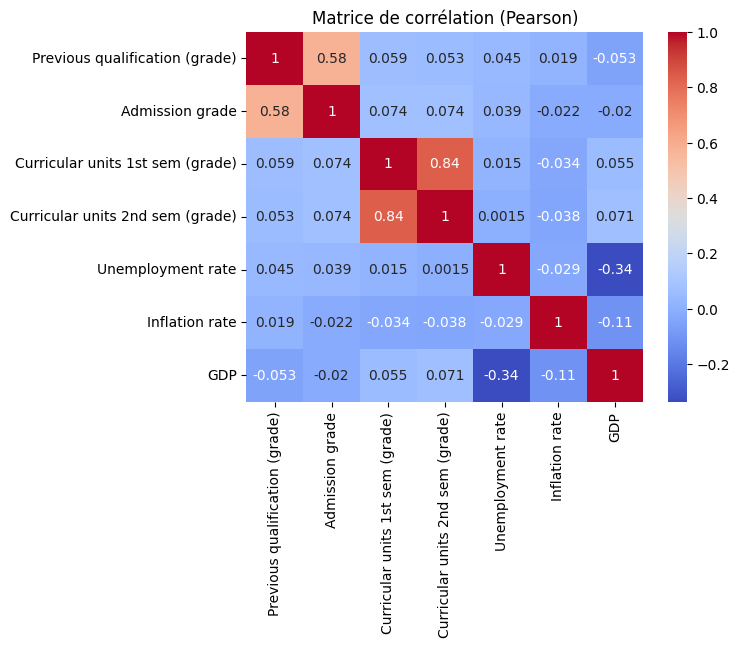

Calcul du VIF :
                           Variable         VIF
0    Previous qualification (grade)  114.040271
1                   Admission grade  107.556332
2  Curricular units 1st sem (grade)   19.449251
3  Curricular units 2nd sem (grade)   16.277563
4                 Unemployment rate   19.516484
5                    Inflation rate    1.804794
6                               GDP    1.122683


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Matrice de corrélation avec Pearson
corr_matrix = df[colonnes_continues].corr(method='pearson')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation (Pearson)")
plt.show()

# Calcul du VIF
X = df[colonnes_continues].dropna()  # Suppression des éventuelles valeurs manquantes
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("Calcul du VIF :")
print(vif_data)


On voit qu'il y a de la colinéarité entre les résultats du premier semestre et du second semestre ainsi que pour le resultat au test d'admission et le niveau de diplôme obtenu précédemment

In [20]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Supposons que 'df_continuous' soit votre DataFrame contenant les variables continues

# Normalisation des données
scaler = StandardScaler()
df_continuous_scaled = scaler.fit_transform(df[colonnes_continues])

# Initialisation de l'ACP sans spécifier le nombre de composantes
pca = PCA()
pca.fit(df_continuous_scaled)

# Calcul de la variance expliquée cumulée
variance_expliquee_cumulee = np.cumsum(pca.explained_variance_ratio_)

# Détermination du nombre de composantes nécessaires pour atteindre 95% de variance expliquée
nombre_composantes = np.argmax(variance_expliquee_cumulee >= 0.8) + 1

print(f"En faisant une ACP uniquement sur les valeurs continue, le nombre de composantes pour expliquer 80% de la variance est : {nombre_composantes}")



En faisant une ACP uniquement sur les valeurs continue, le nombre de composantes pour expliquer 80% de la variance est : 4


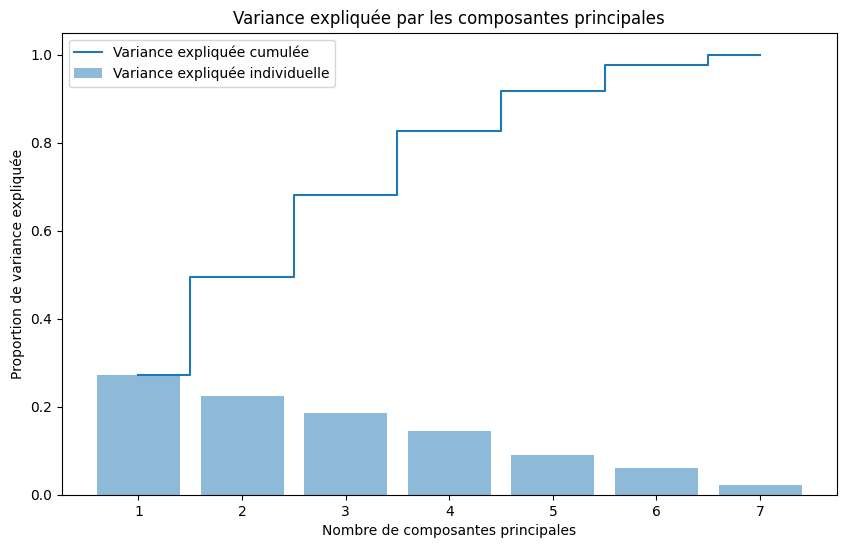

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.5, align='center', label='Variance expliquée individuelle')
plt.step(range(1, len(variance_expliquee_cumulee) + 1), variance_expliquee_cumulee, where='mid', label='Variance expliquée cumulée')
plt.xlabel('Nombre de composantes principales')
plt.ylabel('Proportion de variance expliquée')
plt.legend(loc='best')
plt.title('Variance expliquée par les composantes principales')
plt.show()


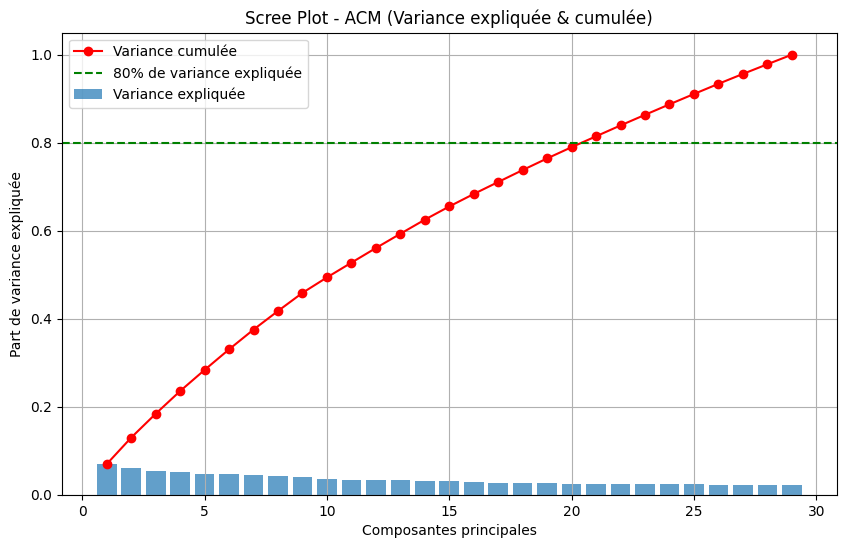

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import prince

# --- Sélection des colonnes catégorielles ---
#categorical_data = df[categorical_cols]

# --- Application de l'ACM ---
mca = prince.MCA(n_components=len(colonnes_categoriques), random_state=42)
mca = mca.fit(df[colonnes_categoriques])

# --- Récupération des valeurs propres ---
eig_values = np.array(mca.eigenvalues_)
explained_var = eig_values / eig_values.sum()
cumulative_var = np.cumsum(explained_var)

# --- Affichage du Scree Plot ---
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_var)+1), explained_var, alpha=0.7, label='Variance expliquée')
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o', color='red', label='Variance cumulée')
plt.xlabel('Composantes principales')
plt.ylabel('Part de variance expliquée')
plt.title("Scree Plot - ACM (Variance expliquée & cumulée)")
plt.axhline(y=0.80, color='green', linestyle='--', label='80% de variance expliquée')
plt.legend()
plt.grid(True)
plt.show()


In [32]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

# Identifier les colonnes catégorielles et numériques (hors Target)
#categorical_cols = df.select_dtypes(include='int64').columns
#numerical_cols = df.select_dtypes(include='float64').columns

# Identifier les colonnes catégorielles et numériques *correctement*
categorical_cols_names = ['Marital status', 'Application mode', 'Course', 'Daytime/evening attendance\t',
                          'Previous qualification', 'Nacionality', 'Mother\'s qualification',
                          'Father\'s qualification', 'Mother\'s occupation', 'Father\'s occupation',
                          'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date',
                          'Gender', 'Scholarship holder', 'International'] # Ajoutez ici toutes les colonnes catégorielles

numerical_cols_names = ['Application order', 'Previous qualification (grade)', 'Admission grade',
                        'Age at enrollment', 'Curricular units 1st sem (credited)',
                        'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)',
                        'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)',
                        'Curricular units 1st sem (without evaluations)',
                        'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
                        'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
                        'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)',
                        'Unemployment rate', 'Inflation rate', 'GDP'] # Ajoutez ici toutes les colonnes numériques

# Sélectionner les données catégorielles et numériques
categorical_data = df[categorical_cols_names]
numerical_data = df[numerical_cols_names]

# Encoder les variables catégorielles
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_categorical_data = encoder.fit_transform(categorical_data)
encoded_feature_names = encoder.get_feature_names_out(categorical_cols_names)
encoded_df = pd.DataFrame(encoded_categorical_data, columns=encoded_feature_names, index=df.index)

# Standardiser les données numériques
scaler = StandardScaler()
scaled_numerical_data = scaler.fit_transform(numerical_data)
scaled_numerical_df = pd.DataFrame(scaled_numerical_data, columns=numerical_cols_names, index=df.index)

# Combiner les variables numériques standardisées et les variables catégorielles encodées
full_data = pd.concat([scaled_numerical_df, encoded_df], axis=1)

# Appliquer l'ACP
pca = PCA(n_components=0.95)
principal_components = pca.fit_transform(full_data)

# Créer un nouveau DataFrame avec les composantes principales
pca_df = pd.DataFrame(data=principal_components)

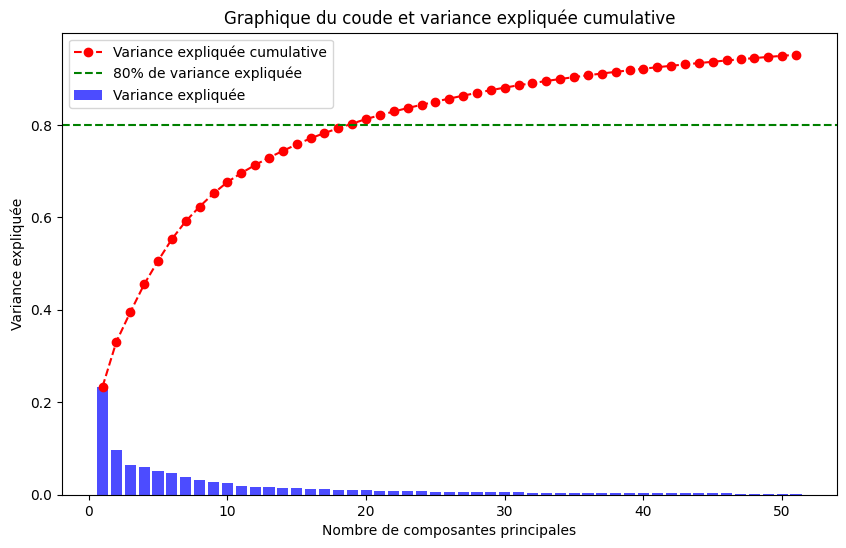

In [33]:
# Variance expliquée par chaque composante et graphique du coude
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, color='blue', label='Variance expliquée')
plt.plot(range(1, len(explained_variance) + 1), explained_variance.cumsum(), marker='o', color='red', linestyle='--', label='Variance expliquée cumulative')
plt.axhline(y=0.80, color='green', linestyle='--', label='80% de variance expliquée')
plt.title('Graphique du coude et variance expliquée cumulative')
plt.xlabel('Nombre de composantes principales')
plt.ylabel('Variance expliquée')
plt.legend()
plt.show()

On arrive donc à expliquer 80% de la variance avec 16 composantes, et 90% de variance avec 21 composantes

On verra donc la précision du modele de prédiction en fonction du nombre de composantes afin de faire le meilleur choix

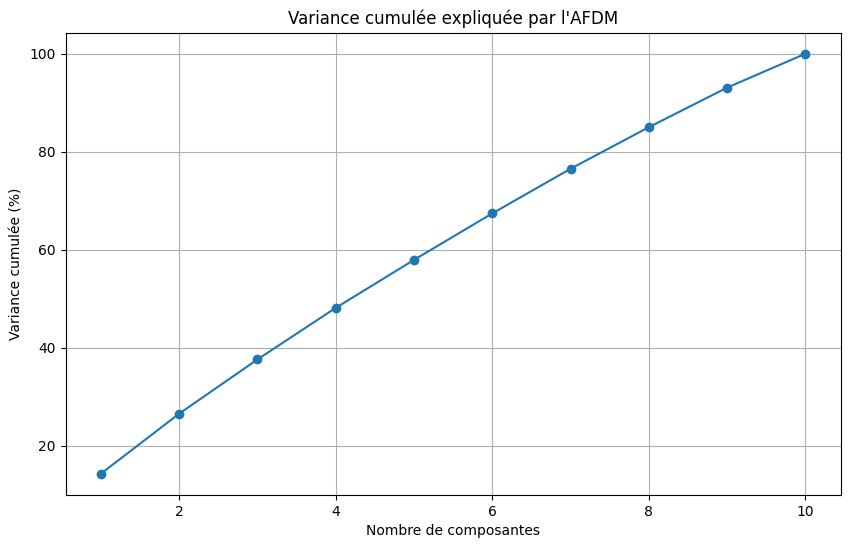

Composante 1 : 14.25%
Composante 2 : 12.26%
Composante 3 : 11.08%
Composante 4 : 10.53%
Composante 5 : 9.80%
Composante 6 : 9.49%
Composante 7 : 9.11%
Composante 8 : 8.49%
Composante 9 : 8.08%
Composante 10 : 6.92%

Variance cumulée avec 10 composantes : 100.00%


In [42]:
import pandas as pd
import prince
import matplotlib.pyplot as plt

# === 1. Séparer les variables ===
# Variables continues
numerical_cols = df.select_dtypes(include='float64').columns.tolist()

# Variables catégorielles (hors Target)
categorical_cols = df.select_dtypes(include='int64').columns.tolist()


# === 2. Appliquer l'AFDM ===
afdm = prince.FAMD(
    n_components=10,  # tu peux ajuster selon ton besoin
    random_state=42
)

afdm = afdm.fit(df[numerical_cols + categorical_cols])

# === 3. Résultats ===
famd_coordinates = afdm.row_coordinates(df[numerical_cols + categorical_cols])

# === 4. Variance expliquée (méthode alternative) ===
eigenvalues = afdm.eigenvalues_
explained_variance = eigenvalues / eigenvalues.sum()

# Plot de la variance cumulée
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance)+1),
         pd.Series(explained_variance).cumsum()*100,
         marker='o')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance cumulée (%)')
plt.title('Variance cumulée expliquée par l\'AFDM')
plt.grid(True)
plt.show()

# === 5. Afficher la variance expliquée ===
for i, var in enumerate(explained_variance):
    print(f"Composante {i+1} : {var*100:.2f}%")

print(f"\nVariance cumulée avec 10 composantes : {sum(explained_variance)*100:.2f}%")

In [40]:
print(prince.__version__)

0.16.0
